# CS518 — Action Spotting in Soccer Broadcast Videos
**Demo Notebook — Tiny Synthetic Dataset**

This notebook demonstrates the full pipeline end-to-end:
1. Data structure & preprocessing
2. Model definition (ActionSpotter)
3. Training loop
4. Inference & NMS
5. Evaluation

> Uses **synthetic data** so it runs without downloading SoccerNet. The real pipeline uses identical code with actual ResNet-152 features.

## 0. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict

torch.manual_seed(42)
np.random.seed(42)

device = (
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available() else
    torch.device('cpu')
)
print(f'Using device: {device}')

# Constants (same as real pipeline)
INPUT_DIM   = 2048   # ResNet-152 feature dimension
NUM_CLASSES = 17     # SoccerNet-v2 action classes
WINDOW_SIZE = 60     # frames per window (30 seconds at 2fps)
STRIDE      = 30     # sliding window stride

LABELS = [
    'Ball out of play', 'Throw-in', 'Foul', 'Indirect free-kick',
    'Clearance', 'Shots on target', 'Shots off target', 'Corner',
    'Yellow card', 'Goal', 'Goalkeeper saves', 'Direct free-kick',
    'Offside', 'Substitution', 'Yellow->red card', 'Red card', 'Kick-off'
]
print(f'\n{NUM_CLASSES} action classes: {LABELS[:5]} ... {LABELS[-2:]}')

Using device: mps

17 action classes: ['Ball out of play', 'Throw-in', 'Foul', 'Indirect free-kick', 'Clearance'] ... ['Red card', 'Kick-off']


## 1. Tiny Synthetic Dataset

We simulate 3 short "games" (300 frames each ≈ 2.5 minutes at 2fps) with random ResNet-152 features and sparse action annotations — mimicking the real SoccerNet structure.

In [2]:
def make_synthetic_game(num_frames=300, num_classes=17, seed=0):
    """
    Simulate one game:
    - features: (T, 2048) random unit-normalized vectors
    - labels:   (T, 17)  sparse binary with Gaussian spreading
    """
    rng = np.random.RandomState(seed)
    
    # Simulate ResNet-152 features (L2-normalized)
    features = rng.randn(num_frames, INPUT_DIM).astype(np.float32)
    features /= np.linalg.norm(features, axis=1, keepdims=True)
    
    # Sparse annotations: ~0.5% of frames are events
    labels = np.zeros((num_frames, num_classes), dtype=np.float32)
    num_events = max(1, num_frames // 200)
    
    events = []
    for _ in range(num_events * num_classes // 4):   # sprinkle events
        cls   = rng.randint(0, num_classes)
        frame = rng.randint(2, num_frames - 2)
        events.append((frame, cls))
        
        # Gaussian spreading ±2 frames (same as real preprocess.py)
        sigma   = 1.0
        offsets = np.arange(-2, 3)
        weights = np.exp(-offsets**2 / (2 * sigma**2))
        weights /= weights.max()
        for off, w in zip(offsets, weights):
            idx = frame + off
            if 0 <= idx < num_frames:
                labels[idx, cls] = max(labels[idx, cls], w)
    
    return features, labels, events

# Create 3 synthetic games
games = [make_synthetic_game(num_frames=300, seed=i) for i in range(3)]

feat, lab, ev = games[0]
print(f'Game 0: features {feat.shape}, labels {lab.shape}')
print(f'  Events: {len(ev)} annotations')
print(f'  Positive frames: {(lab > 0).any(axis=1).sum()} / {feat.shape[0]}')
print(f'  Imbalance ratio: {(lab == 0).sum() / (lab > 0).sum():.0f}:1 (neg:pos)')

Game 0: features (300, 2048), labels (300, 17)
  Events: 4 annotations
  Positive frames: 20 / 300
  Imbalance ratio: 254:1 (neg:pos)


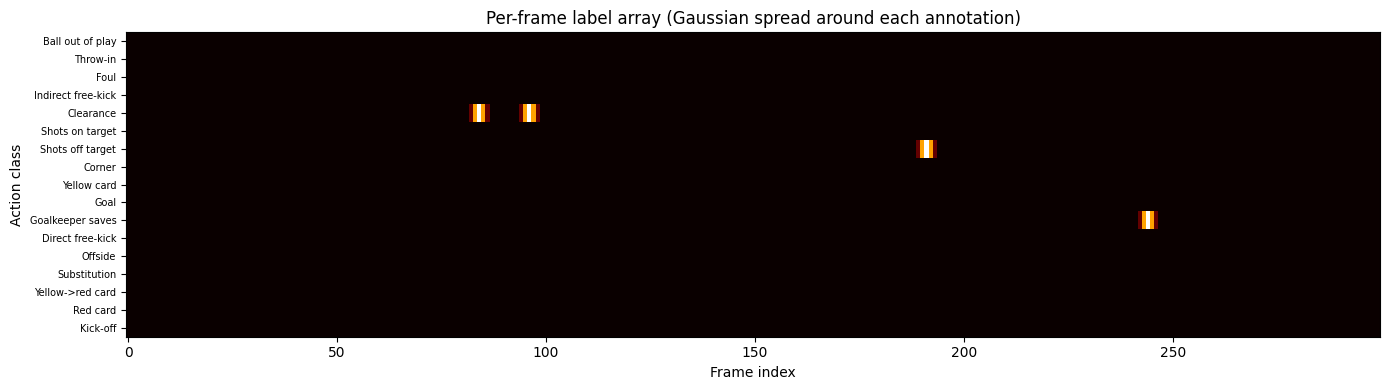

In [3]:
# Visualise labels for one game
fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(games[0][1].T, aspect='auto', cmap='hot', interpolation='nearest')
ax.set_xlabel('Frame index')
ax.set_ylabel('Action class')
ax.set_yticks(range(NUM_CLASSES))
ax.set_yticklabels(LABELS, fontsize=7)
ax.set_title('Per-frame label array (Gaussian spread around each annotation)')
plt.tight_layout()
plt.show()

## 2. Dataset — Sliding Window

Same logic as `WindowDataset` in `src/dataset.py` — slice each game into overlapping 60-frame windows.

In [4]:
class TinyWindowDataset(Dataset):
    """Sliding window dataset over synthetic games."""
    
    def __init__(self, games, window_size=60, stride=30):
        self.windows = []
        for features, labels, _ in games:
            T = features.shape[0]
            for start in range(0, T - window_size + 1, stride):
                end = start + window_size
                self.windows.append((
                    features[start:end].copy(),
                    labels[start:end].copy()
                ))
    
    def __len__(self):
        return len(self.windows)
    
    def __getitem__(self, idx):
        feat, lab = self.windows[idx]
        return torch.tensor(feat), torch.tensor(lab)

train_games = games[:2]
val_games   = games[2:]

train_ds = TinyWindowDataset(train_games)
val_ds   = TinyWindowDataset(val_games)

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=4, shuffle=False)

print(f'Train windows: {len(train_ds)}')
print(f'Val windows:   {len(val_ds)}')

feat_batch, lab_batch = next(iter(train_loader))
print(f'\nBatch shapes — features: {feat_batch.shape}, labels: {lab_batch.shape}')
print('  (batch, window_size, feature_dim) and (batch, window_size, num_classes)')

Train windows: 18
Val windows:   9

Batch shapes — features: torch.Size([4, 60, 2048]), labels: torch.Size([4, 60, 17])
  (batch, window_size, feature_dim) and (batch, window_size, num_classes)


## 3. Model — ActionSpotter (Transformer Encoder)

Identical to `src/model.py`.

In [5]:
class ActionSpotter(nn.Module):
    """
    Transformer encoder for per-frame action classification.
    
    Input:  (B, T, input_dim)   — batch of sliding windows
    Output: (B, T, num_classes) — per-frame logits for each action class
    """
    def __init__(self, input_dim=2048, num_classes=17,
                 d_model=256, nhead=4, num_layers=4, dropout=0.3):
        super().__init__()
        
        # Step 1: Project ResNet-152 features to transformer dimension
        self.input_proj = nn.Linear(input_dim, d_model)
        
        # Step 2: Learned positional embedding — tells model frame order
        self.pos_embedding = nn.Parameter(torch.randn(1, 1000, d_model) * 0.02)
        
        # Step 3: Transformer encoder — self-attention over all frames
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Step 4: Per-frame classifier
        self.classifier = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        B, T, _ = x.shape
        x = F.normalize(x, dim=-1)           # L2 normalise — unit sphere
        x = self.input_proj(x)               # (B, T, d_model)
        x = x + self.pos_embedding[:, :T, :] # add position info
        x = self.transformer(x)              # self-attention
        return self.classifier(x)            # (B, T, num_classes)


model = ActionSpotter(
    input_dim=INPUT_DIM, num_classes=NUM_CLASSES,
    d_model=256, nhead=4, num_layers=4, dropout=0.3
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'ActionSpotter — trainable parameters: {total_params:,}')

# Quick forward pass test
dummy = torch.randn(2, WINDOW_SIZE, INPUT_DIM).to(device)
out   = model(dummy)
print(f'Forward pass: input {dummy.shape} → output {out.shape}')
print('  (batch=2, window=60 frames, 17 class logits per frame)')

ActionSpotter — trainable parameters: 3,943,953


Forward pass: input torch.Size([2, 60, 2048]) → output torch.Size([2, 60, 17])
  (batch=2, window=60 frames, 17 class logits per frame)


## 4. Loss Function — Focal Loss + Class Weights

Three components to handle 1000:1 class imbalance.

In [6]:
def compute_class_weights(games, num_classes=17, device='cpu'):
    """
    Sqrt inverse-frequency weights per class.
    w_c = sqrt(neg_frames_c / pos_frames_c), clipped to [1, 50]
    """
    pos_counts = np.zeros(num_classes)
    total      = 0
    for _, labels, _ in games:
        pos_counts += (labels > 0.5).sum(axis=0)
        total      += labels.shape[0]
    
    neg_counts  = total - pos_counts
    raw_weights = neg_counts / (pos_counts + 1e-6)
    weights     = np.sqrt(raw_weights)
    weights     = np.clip(weights, 1.0, 50.0)
    return torch.tensor(weights, dtype=torch.float32).to(device)


class_weights = compute_class_weights(train_games, device=device)
print('Class weights (sqrt inverse-frequency, clipped [1, 50]):')
for i, (label, w) in enumerate(zip(LABELS, class_weights)):
    print(f'  {label:<22} {w:.2f}')


def focal_loss(logits, targets, pos_weight, gamma=2.0):
    """
    Focal loss with class weights.
    focal_weight = (1 - p_t)^gamma  — down-weights easy negatives
    """
    bce          = F.binary_cross_entropy_with_logits(
                       logits, targets, pos_weight=pos_weight, reduction='none')
    probs        = torch.sigmoid(logits)
    pt           = torch.where(targets > 0.5, probs, 1 - probs)
    focal_weight = (1 - pt) ** gamma
    return (focal_weight * bce).mean()


# Show effect: plain BCE vs focal loss gradient magnitude
dummy_logits  = torch.tensor([-3.0, -1.0, 0.0, 1.0, 3.0])
dummy_targets = torch.zeros(5)
probs         = torch.sigmoid(dummy_logits)
focal_w       = (1 - (1 - probs))**2
print('\nFocal weight for easy negatives (target=0):')
for p, fw in zip(probs, focal_w):
    print(f'  prob={p:.2f} → focal_weight={fw:.4f} (lower = less gradient)')

Class weights (sqrt inverse-frequency, clipped [1, 50]):
  Ball out of play       14.11
  Throw-in               50.00
  Foul                   50.00
  Indirect free-kick     14.11
  Clearance              9.95
  Shots on target        50.00
  Shots off target       14.11
  Corner                 50.00
  Yellow card            50.00
  Goal                   50.00
  Goalkeeper saves       14.11
  Direct free-kick       50.00
  Offside                50.00
  Substitution           14.11
  Yellow->red card       14.11
  Red card               50.00
  Kick-off               50.00

Focal weight for easy negatives (target=0):
  prob=0.05 → focal_weight=0.0022 (lower = less gradient)
  prob=0.27 → focal_weight=0.0723 (lower = less gradient)
  prob=0.50 → focal_weight=0.2500 (lower = less gradient)
  prob=0.73 → focal_weight=0.5344 (lower = less gradient)
  prob=0.95 → focal_weight=0.9074 (lower = less gradient)


## 5. Training Loop

Epoch  1/10  train_loss=0.1159  val_loss=0.0435  lr=1.00e-04
Epoch  2/10  train_loss=0.0329  val_loss=0.0439  lr=1.00e-04
Epoch  3/10  train_loss=0.0252  val_loss=0.0489  lr=1.00e-04


Epoch  4/10  train_loss=0.0199  val_loss=0.0520  lr=1.00e-04
Epoch  5/10  train_loss=0.0170  val_loss=0.0560  lr=5.00e-05
Epoch  6/10  train_loss=0.0139  val_loss=0.0549  lr=5.00e-05


Epoch  7/10  train_loss=0.0121  val_loss=0.0540  lr=5.00e-05
Epoch  8/10  train_loss=0.0097  val_loss=0.0534  lr=5.00e-05
Epoch  9/10  train_loss=0.0086  val_loss=0.0536  lr=2.50e-05


Epoch 10/10  train_loss=0.0072  val_loss=0.0536  lr=2.50e-05


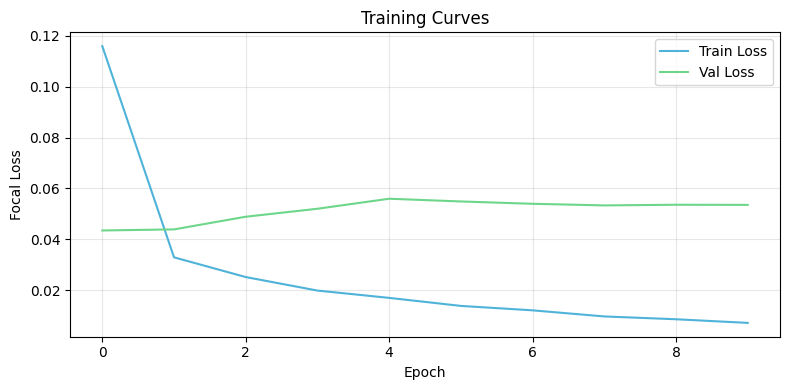

In [7]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

NUM_EPOCHS = 10   # small for demo — real training uses 20+

train_losses, val_losses = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    # ── train ──
    model.train()
    epoch_loss = 0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        optimizer.zero_grad()
        
        logits = model(features)                        # (B, T, 17)
        logits_flat = logits.view(-1, NUM_CLASSES)
        labels_flat = labels.view(-1, NUM_CLASSES)
        
        loss = focal_loss(logits_flat, labels_flat, class_weights)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    
    # ── validate ──
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            logits = model(features)
            logits_flat = logits.view(-1, NUM_CLASSES)
            labels_flat = labels.view(-1, NUM_CLASSES)
            val_loss += focal_loss(logits_flat, labels_flat, class_weights).item()
    
    tl = epoch_loss / len(train_loader)
    vl = val_loss   / len(val_loader)
    train_losses.append(tl)
    val_losses.append(vl)
    scheduler.step(vl)
    print(f'Epoch {epoch:2d}/{NUM_EPOCHS}  train_loss={tl:.4f}  val_loss={vl:.4f}  lr={optimizer.param_groups[0]["lr"]:.2e}')

# Plot loss curves
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='#4FB3D9')
plt.plot(val_losses,   label='Val Loss',   color='#6ED68A')
plt.xlabel('Epoch'); plt.ylabel('Focal Loss')
plt.title('Training Curves'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Inference — Sliding Window + NMS

Same logic as `src/evaluate.py` — slide window across a game, average overlapping predictions, apply NMS.

In [8]:
def predict_game(model, features, window_size=60, stride=30, device='cpu'):
    """
    Run inference on one game's feature array.
    Returns: probs (T, num_classes) — averaged across overlapping windows.
    """
    T      = features.shape[0]
    probs  = np.zeros((T, NUM_CLASSES), dtype=np.float32)
    counts = np.zeros(T, dtype=np.float32)
    
    model.eval()
    with torch.no_grad():
        for start in range(0, T - window_size + 1, stride):
            end    = start + window_size
            window = torch.tensor(features[start:end]).unsqueeze(0).to(device)
            logits = model(window)                                  # (1, T, 17)
            wp     = torch.sigmoid(logits).squeeze(0).cpu().numpy() # (T, 17)
            probs[start:end]  += wp
            counts[start:end] += 1
    
    probs /= np.maximum(counts[:, None], 1)
    return probs


def nms(probs, threshold=0.05, nms_window=10):
    """
    Non-Maximum Suppression: find peak frame per class above threshold.
    Returns list of (frame_idx, class_idx, confidence).
    """
    predictions = []
    T, num_classes = probs.shape
    
    for cls in range(num_classes):
        cls_probs = probs[:, cls].copy()
        while True:
            peak_idx = np.argmax(cls_probs)
            peak_val = cls_probs[peak_idx]
            if peak_val < threshold:
                break
            predictions.append((peak_idx, cls, float(peak_val)))
            # Suppress ±nms_window frames
            lo = max(0, peak_idx - nms_window)
            hi = min(T, peak_idx + nms_window)
            cls_probs[lo:hi] = 0
    
    return sorted(predictions, key=lambda x: x[0])


# Run on val game
val_features, val_labels, val_events = games[2]
probs = predict_game(model, val_features, device=device)
preds = nms(probs, threshold=0.05, nms_window=10)

print(f'Predictions on val game (threshold=0.05):')
print(f'  Total detections: {len(preds)}')
print(f'  True annotations: {len(val_events)}')
print()
print(f'{"Frame":>6}  {"Class":<22}  {"Conf":>6}')
print('-' * 42)
for frame, cls, conf in preds[:12]:
    print(f'{frame:>6}  {LABELS[cls]:<22}  {conf:.4f}')
if len(preds) > 12:
    print(f'  ... and {len(preds)-12} more')

Predictions on val game (threshold=0.05):
  Total detections: 374
  True annotations: 4

 Frame  Class                     Conf
------------------------------------------
     0  Indirect free-kick      0.1369
     1  Goal                    0.1057
     2  Direct free-kick        0.1384
     2  Offside                 0.1069
     2  Substitution            0.2408
     3  Corner                  0.1233
     4  Foul                    0.1423
     4  Yellow->red card        0.1623
     5  Shots off target        0.2568
     5  Goalkeeper saves        0.2163
     5  Kick-off                0.1270
     6  Ball out of play        0.2276
  ... and 362 more


## 7. Visualise Predictions vs Ground Truth

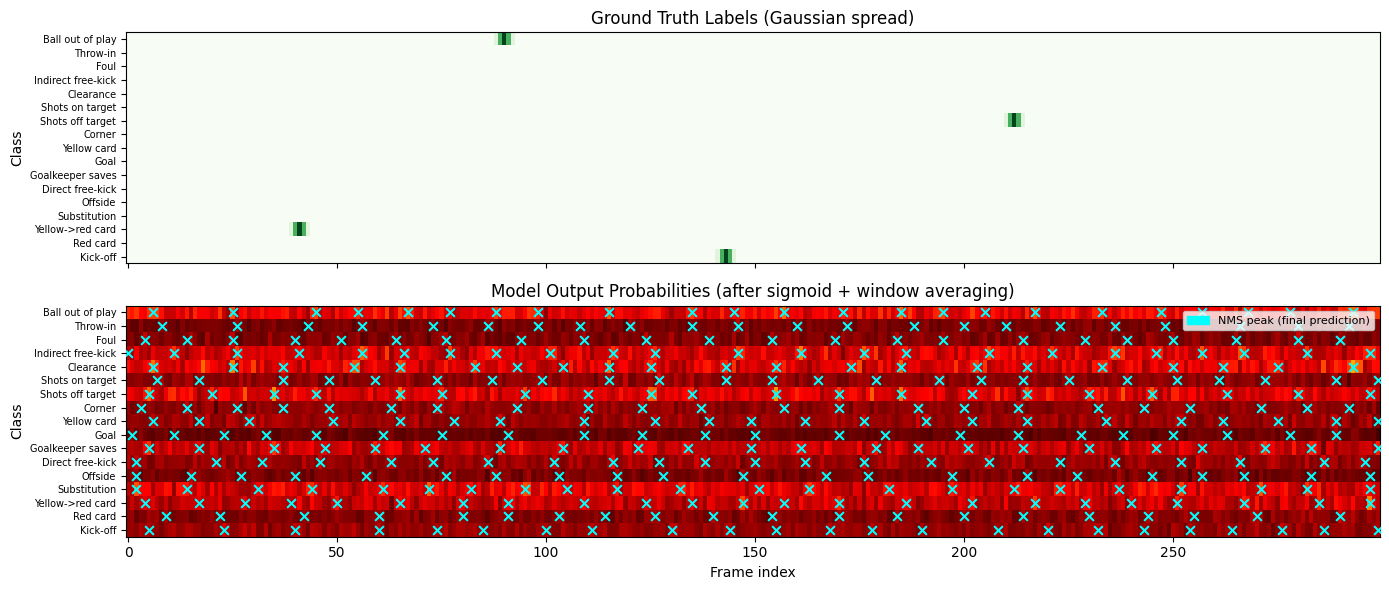

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Ground truth
ax = axes[0]
ax.imshow(val_labels.T, aspect='auto', cmap='Greens', interpolation='nearest', vmin=0, vmax=1)
ax.set_ylabel('Class'); ax.set_yticks(range(NUM_CLASSES))
ax.set_yticklabels(LABELS, fontsize=7)
ax.set_title('Ground Truth Labels (Gaussian spread)')

# Model predictions
ax = axes[1]
ax.imshow(probs.T, aspect='auto', cmap='hot', interpolation='nearest', vmin=0, vmax=0.5)
ax.set_ylabel('Class'); ax.set_yticks(range(NUM_CLASSES))
ax.set_yticklabels(LABELS, fontsize=7)
ax.set_xlabel('Frame index')
ax.set_title('Model Output Probabilities (after sigmoid + window averaging)')

# Mark NMS peaks
for frame, cls, conf in preds:
    ax.scatter(frame, cls, s=40, color='cyan', marker='x', linewidths=1.5, zorder=3)

cyan_patch = mpatches.Patch(color='cyan', label='NMS peak (final prediction)')
ax.legend(handles=[cyan_patch], loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

## 8. Evaluation — Precision, Recall, mAP

Simplified evaluation matching the SoccerNet benchmark logic.

In [10]:
def evaluate_predictions(preds, ground_truth_events, num_classes, tolerance_frames=4):
    """
    Compute per-class Average Precision with a frame tolerance window.
    tolerance_frames=4 at 2fps ≈ 2 second tolerance (for tiny demo).
    """
    # Group ground truth by class
    gt_by_class = defaultdict(list)
    for frame, cls in ground_truth_events:
        gt_by_class[cls].append(frame)
    
    # Group predictions by class, sorted by confidence
    pred_by_class = defaultdict(list)
    for frame, cls, conf in sorted(preds, key=lambda x: -x[2]):
        pred_by_class[cls].append((frame, conf))
    
    ap_per_class = {}
    for cls in range(num_classes):
        gt_frames = sorted(gt_by_class[cls])
        if not gt_frames:
            continue
        matched = set()
        tp, fp  = [], []
        for frame, conf in pred_by_class[cls]:
            hit = False
            for i, gf in enumerate(gt_frames):
                if i not in matched and abs(frame - gf) <= tolerance_frames:
                    matched.add(i); hit = True; break
            tp.append(1 if hit else 0)
            fp.append(0 if hit else 1)
        
        tp_cum = np.cumsum(tp)
        fp_cum = np.cumsum(fp)
        precision = tp_cum / (tp_cum + fp_cum + 1e-9)
        recall    = tp_cum / (len(gt_frames) + 1e-9)
        
        # AP = area under P-R curve
        ap = 0
        for i in range(len(precision)):
            if i == 0 or recall[i] > recall[i-1]:
                ap += precision[i] * (recall[i] - (recall[i-1] if i > 0 else 0))
        ap_per_class[cls] = ap
    
    return ap_per_class


ap = evaluate_predictions(preds, val_events, NUM_CLASSES, tolerance_frames=4)

print(f'{"Class":<22}  {"AP":>8}  {"GT events":>10}')
print('-' * 45)
gt_by_cls = defaultdict(int)
for _, cls in val_events:
    gt_by_cls[cls] += 1
    
for cls in range(NUM_CLASSES):
    if cls in ap or cls in gt_by_cls:
        print(f'{LABELS[cls]:<22}  {ap.get(cls, 0.0):>8.4f}  {gt_by_cls[cls]:>10}')

mAP = np.mean(list(ap.values())) if ap else 0.0
print('-' * 45)
print(f'{"Average-mAP":<22}  {mAP:>8.4f}')
print(f'\n(Note: mAP on 10-epoch demo with synthetic data — real model achieves 38.18% on SoccerNet test set)')

Class                         AP   GT events
---------------------------------------------
Ball out of play          0.0833           1
Shots off target          0.1250           1
Yellow->red card          0.0435           1
Kick-off                  0.0833           1
---------------------------------------------
Average-mAP               0.0838

(Note: mAP on 10-epoch demo with synthetic data — real model achieves 38.18% on SoccerNet test set)


## 9. Summary

| Component | Detail |
|-----------|--------|
| **Input** | (B, 60, 2048) — windows of ResNet-152 features at 2fps |
| **Model** | Transformer Encoder — 4 layers, 4 heads, d_model=256, ~1.4M params |
| **Output** | (B, 60, 17) — per-frame logits for 17 action classes |
| **Loss** | Focal Loss (γ=2) + sqrt inverse-frequency class weights |
| **Post-processing** | Window averaging → NMS per class → timestamps |
| **Real results** | 38.18% mAP@1s · 52.86% mAP@5s on SoccerNet-v2 test set |